In [1]:
from nrem_analysis.constant import RAW_DIR, PROCESSED_DIR, INTERIM_DIR, FIGURES_DIR
from pathlib import Path

import numpy as np
import pynapple as nap
import matplotlib.pyplot as plt
import seaborn as sns

from cmap import Colormap
from matplotlib.colors import TwoSlopeNorm
from scipy import stats

MOUSE_IDS = ["99b", "103c", "106b", "107b", "110b"]

cm = Colormap("colorbrewer:Set2")
norm = TwoSlopeNorm(vmin=-25, vcenter=0, vmax=25)
dashed_style = (0, (5, 5))

plt.rcParams.update({
    "figure.dpi":        150,
    "savefig.dpi":       320,
    "font.family":       "sans-serif",
    'font.sans-serif':   "Arial",
    "axes.grid":         False,
    "figure.constrained_layout.use": True,
})

def plot_heatmaps(mats, times, titles, norm=None, cmap="hot", figsize=None):
    """Plot [T, N] matrices as side-by-side heatmaps."""
    n = len(mats)

    if figsize is None:
        figsize = (4 * n, 4)

    fig, axes = plt.subplots(
        1, n, figsize=figsize, sharey=True, squeeze=False
    )
    axes = axes.ravel()

    for ax, mat, time, title in zip(axes, mats, times, titles):
        im = ax.imshow(
            mat.T,
            aspect="auto",
            origin="lower",
            extent=[time[0], time[-1], 0, mat.shape[1]],
            cmap=cmap,
            norm=norm,
        )

        ax.set_title(title)
        fig.colorbar(im, ax=ax)

    return fig, axes

def time_index(t, target):
    return np.argmin(np.abs(t - target))

def amplitude_at_threshold(sta, t, threshold):
    before_idx = time_index(t, -threshold)
    after_idx = time_index(t, threshold)
    return sta[after_idx, :] - sta[before_idx, :]

def plot_scatter_with_regression(ax, x, y, title=None, xlabel=None, ylabel=None, line_color='tab:red', scatter_color='k'):
    fit = stats.linregress(x, y)
    x_fit = np.linspace(x.min(), x.max(), 100)
    y_fit = fit.intercept + fit.slope * x_fit

    ax.scatter(x, y, s=15, c=scatter_color, alpha=0.8)
    ax.plot(x_fit, y_fit, color=line_color, linewidth=0.7, linestyle='--')
    ax.axhline(0, color='0.5', linestyle='--', linewidth=1)
    ax.axvline(0, color='0.5', linestyle='--', linewidth=1)

    label = (
        f'R = {fit.rvalue:.2f}\n'
        f'p = {fit.pvalue:.2g}\n'
    )

    ax.text(0.05, 0.95, label, transform=ax.transAxes, ha='left', va='top', fontsize=14)
    if title is not None:
        ax.set_title(title, fontsize=18)
    if xlabel is not None:
        ax.set_xlabel(xlabel, fontsize=18)
    if ylabel is not None:
        ax.set_ylabel(ylabel, fontsize=18)

In [2]:
tsi = []
sta_nrem = []
midx = []

for mouse_idx, mouse_id in enumerate(MOUSE_IDS):
    turn_units = nap.load_file(PROCESSED_DIR / "dual" / mouse_id / "turn_units.npz")  
    sta_nrem.append(nap.load_file(INTERIM_DIR / "sta" / mouse_id / "sta_nrem_upstate.npz"))
    
    midx.append(np.zeros_like(turn_units['turn_index']) + mouse_idx)
    tsi.append(turn_units['turn_index'])
        
tsi = np.concatenate(tsi)
midx = np.concatenate(midx)

order = np.argsort(tsi)
tsi = tsi[order]
midx = midx[order]

sta_nrem = np.rad2deg(np.column_stack(sta_nrem))[:, order]
sta_original = nap.load_file(PROCESSED_DIR / "dual" / "sta_awake_sorted.npz")

nanmask = np.any(np.isnan(sta_nrem), axis=0)
tsi = tsi[~nanmask]
zero_cross = np.argmin(np.abs(tsi)).item()

midx = midx[~nanmask]
sta_original = sta_original[:, ~nanmask]
sta_nrem = sta_nrem[:, ~nanmask]

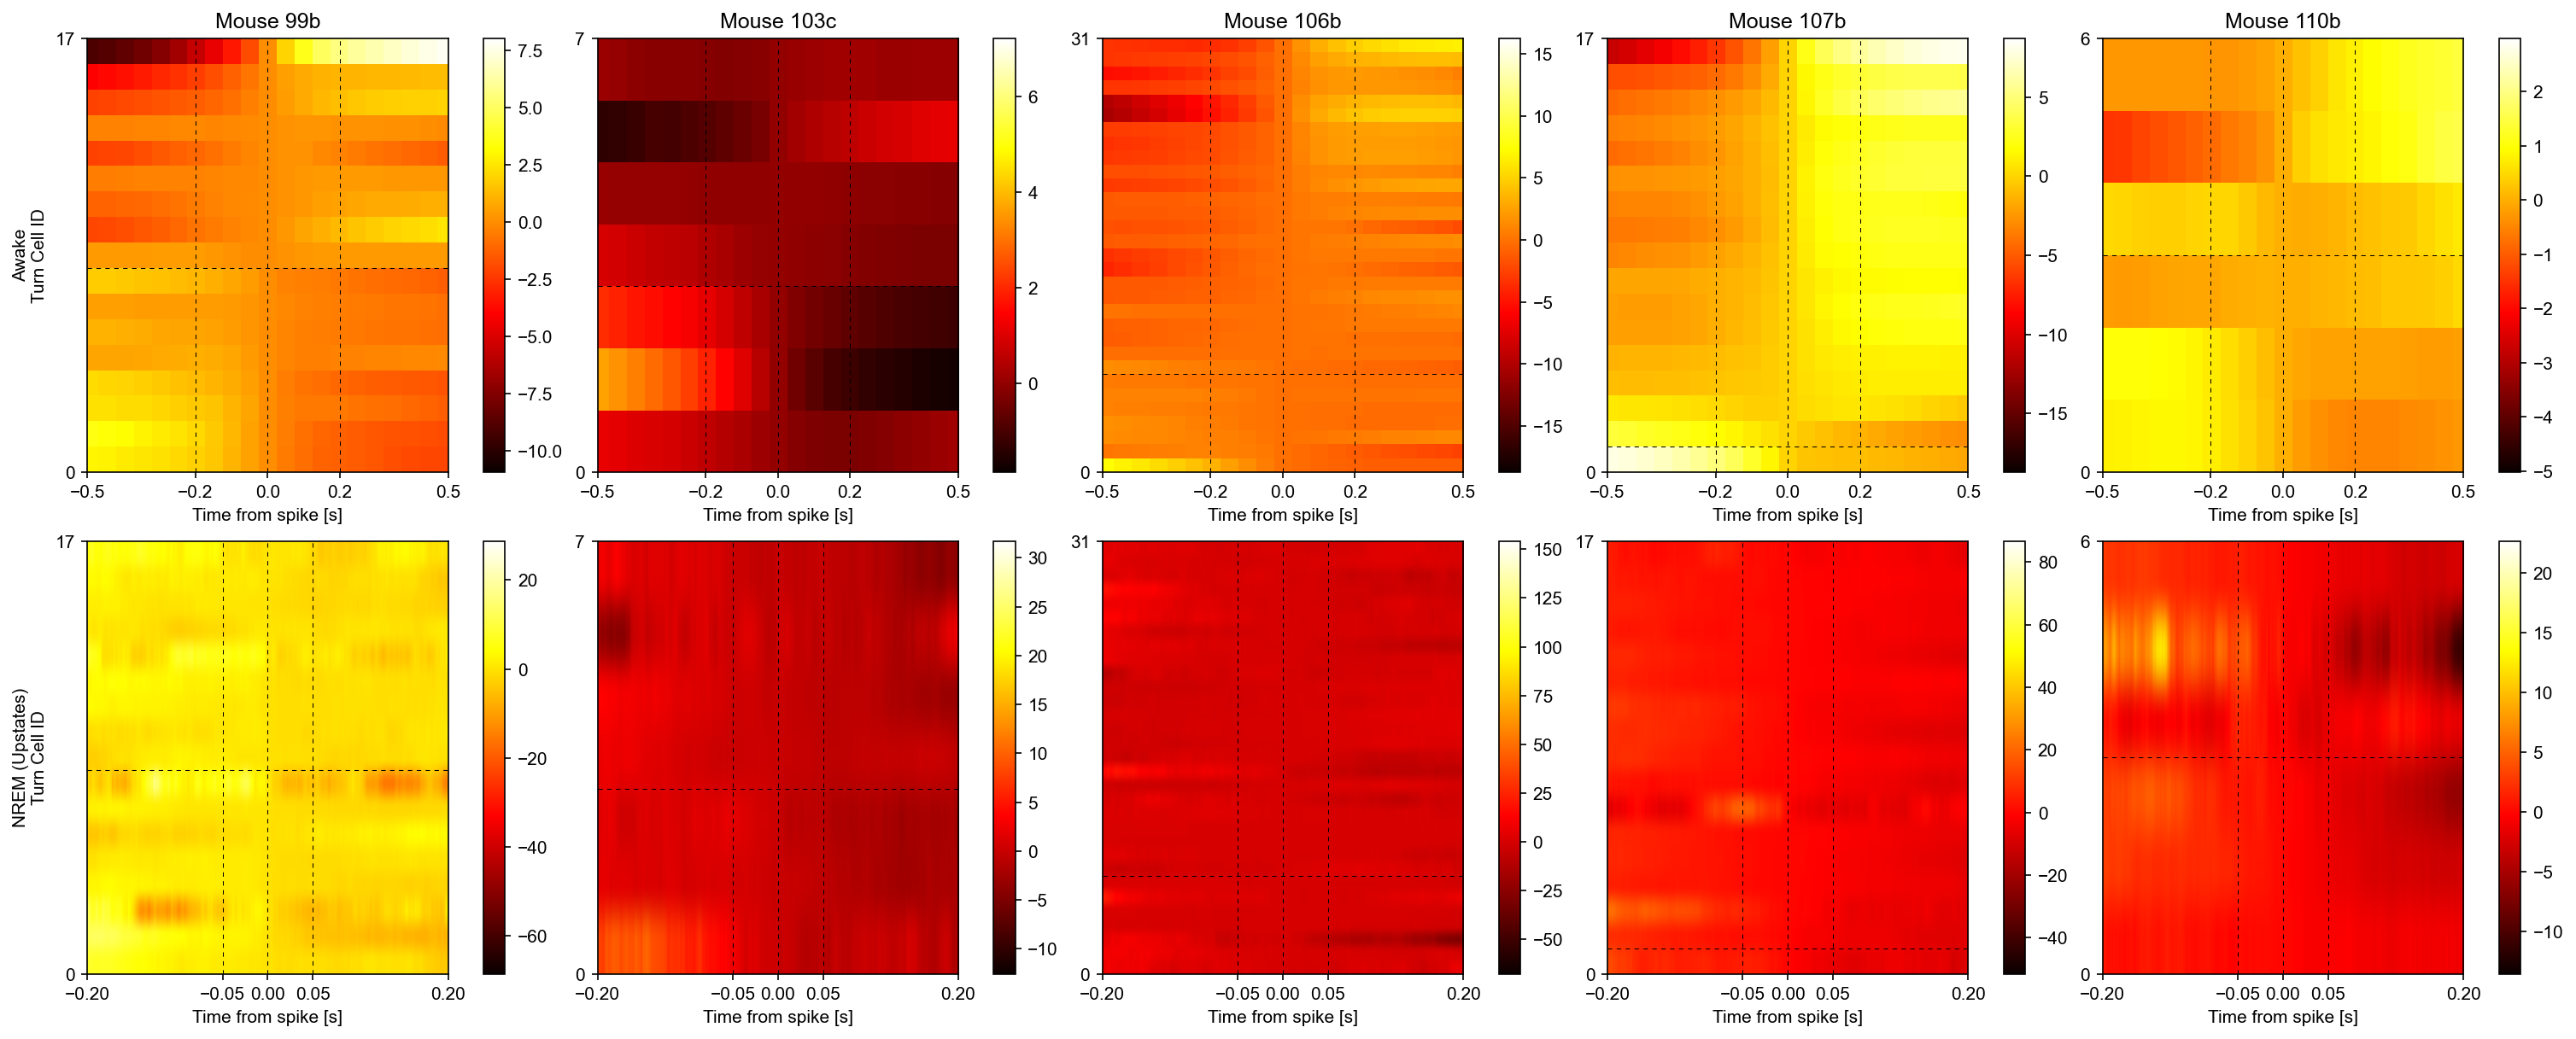

In [7]:
fig, axes = plt.subplots(
    2, len(MOUSE_IDS), figsize=(4 * len(MOUSE_IDS), 8), sharey=False, squeeze=False
)
heatmap_norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
row_specs = [
    ("Awake", sta_original, (-0.5, 0.5), [-0.5, -0.2, 0, 0.2, 0.5], 0.2),
    ("NREM (Upstates)", sta_nrem, (-0.2, 0.2), [-0.2, -0.05, 0, 0.05, 0.2], 0.05),
]

for mouse_idx, mouse_id in enumerate(MOUSE_IDS):
    mouse_mask = midx == mouse_idx
    mouse_zero_cross = np.argmin(np.abs(tsi[mouse_mask])).item()

    for row_idx, (state, sta, xlim, xticks, threshold) in enumerate(row_specs):
        ax = axes[row_idx, mouse_idx]
        mouse_sta = sta.d[:, mouse_mask]

        im = ax.imshow(
            mouse_sta.T,
            aspect="auto",
            origin="lower",
            extent=[sta.t[0], sta.t[-1], 0, mouse_sta.shape[1]],
            cmap="hot",
            # norm=heatmap_norm,
        )

        ax.set_xlabel("Time from spike [s]")
        ax.set_xlim(xlim)
        ax.set_xticks(xticks)
        ax.set_yticks([0, mouse_sta.shape[1]])
        ax.axvline(0, color="k", linestyle=dashed_style, linewidth=0.5)
        ax.axvline(threshold, color="k", linestyle=dashed_style, linewidth=0.5)
        ax.axvline(-threshold, color="k", linestyle=dashed_style, linewidth=0.5)
        ax.axhline(mouse_zero_cross, color="k", linestyle=dashed_style, linewidth=0.5)
        fig.colorbar(im, ax=ax)

        if mouse_idx == 0:
            ax.set_ylabel(f"{state}\nTurn Cell ID")

    axes[0, mouse_idx].set_title(f"Mouse {mouse_id}")

# plt.savefig(FIGURES_DIR / "sta_per_mouse.svg", format='svg', bbox_inches='tight')
# plt.savefig(FIGURES_DIR / "sta_per_mouse.png", format='png', bbox_inches='tight')

plt.show()

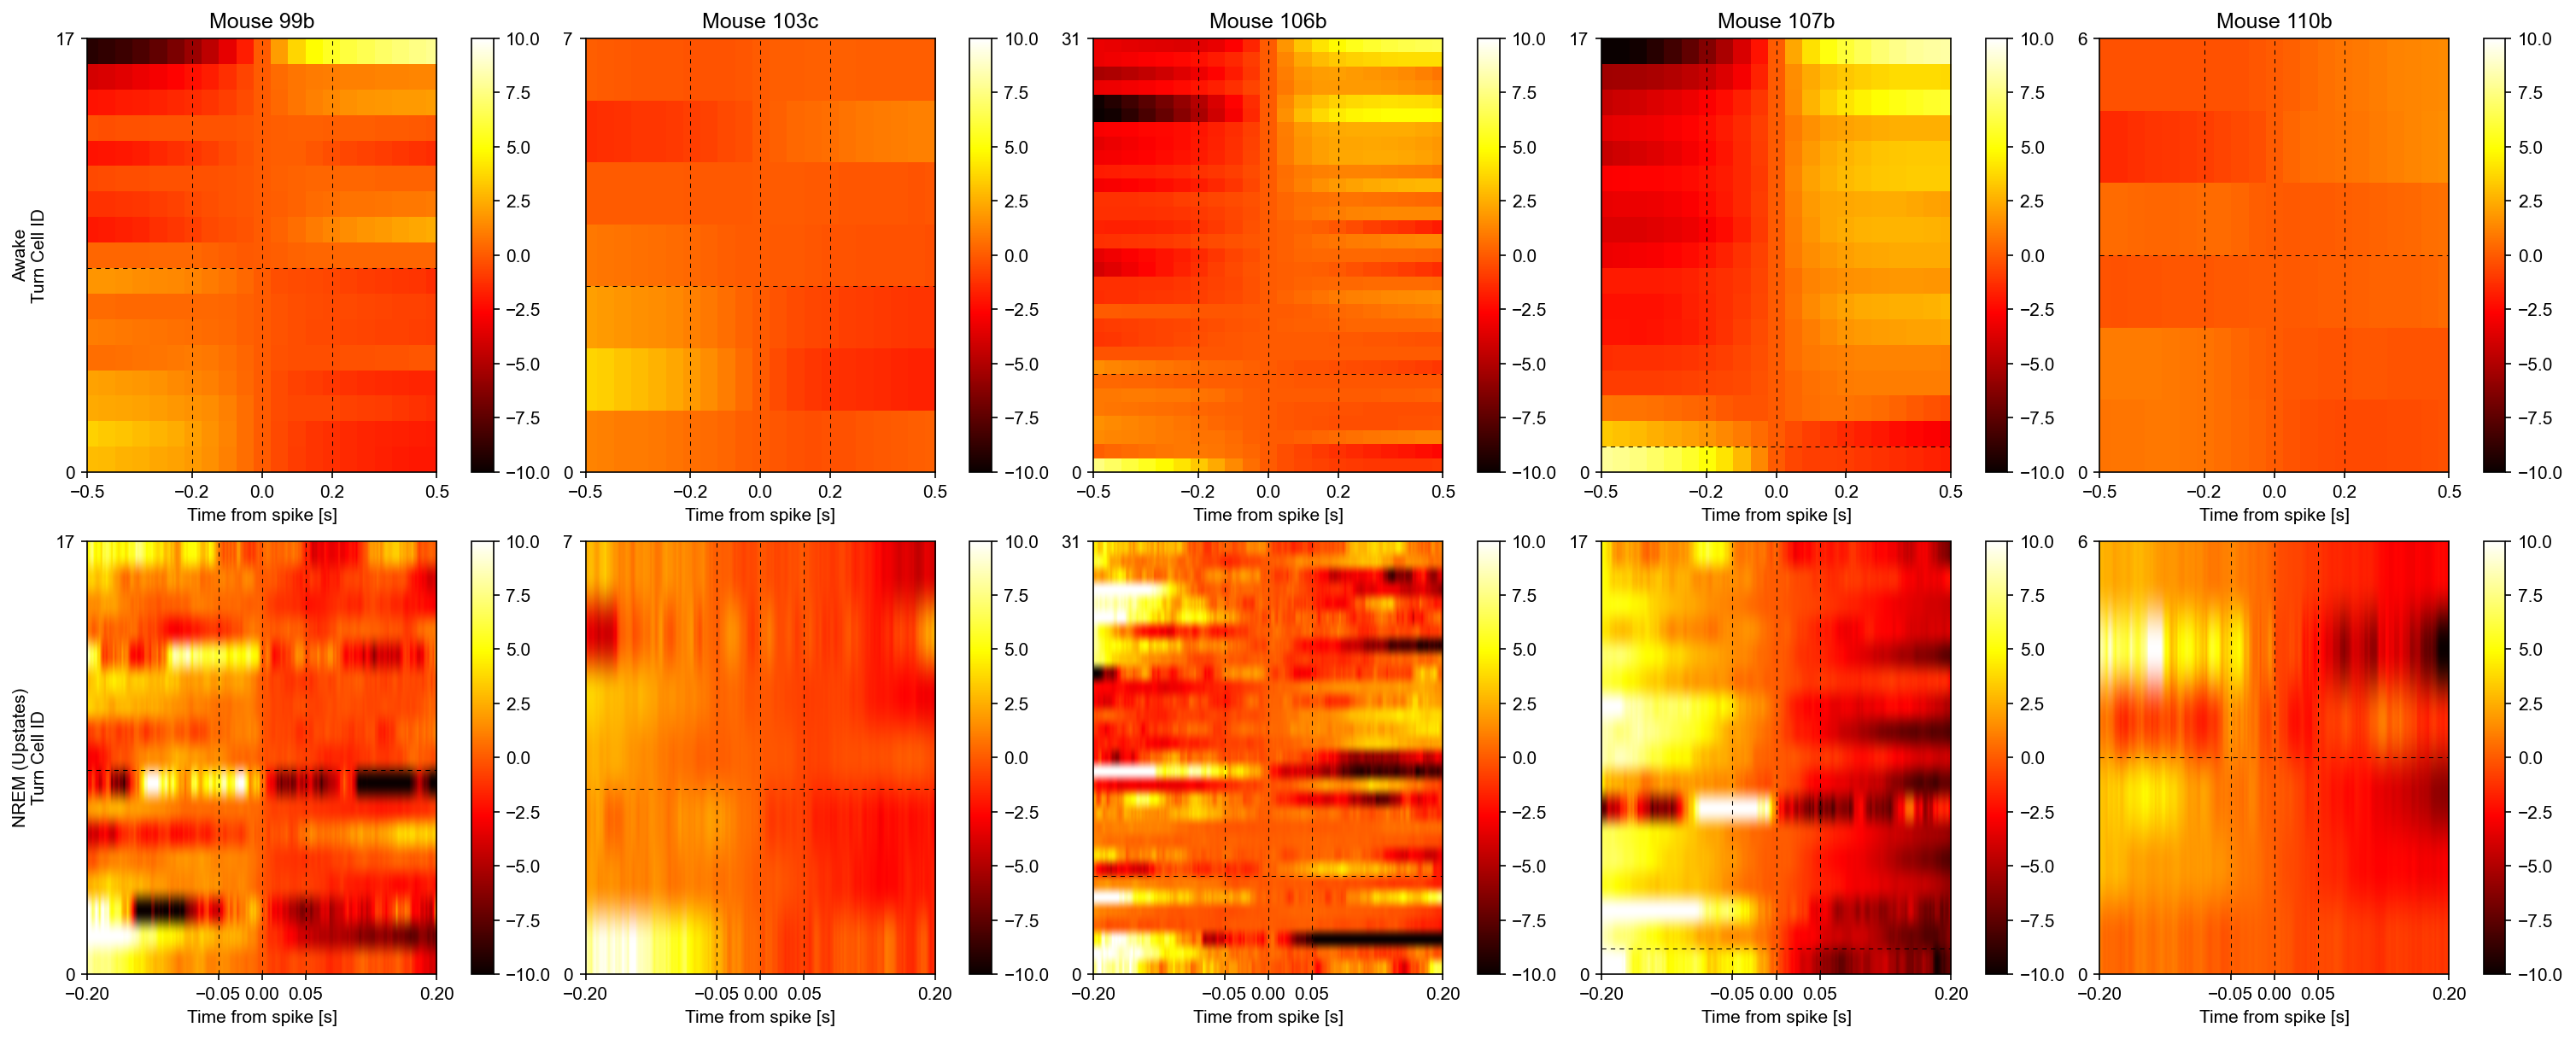

In [9]:
fig, axes = plt.subplots(
    2, len(MOUSE_IDS), figsize=(4 * len(MOUSE_IDS), 8), sharey=False, squeeze=False
)
heatmap_norm = TwoSlopeNorm(vmin=-10, vcenter=0, vmax=10)
row_specs = [
    ("Awake", sta_original, (-0.5, 0.5), [-0.5, -0.2, 0, 0.2, 0.5], 0.2),
    ("NREM (Upstates)", sta_nrem, (-0.2, 0.2), [-0.2, -0.05, 0, 0.05, 0.2], 0.05),
]

for mouse_idx, mouse_id in enumerate(MOUSE_IDS):
    mouse_mask = midx == mouse_idx
    mouse_zero_cross = np.argmin(np.abs(tsi[mouse_mask])).item()

    for row_idx, (state, sta, xlim, xticks, threshold) in enumerate(row_specs):
        ax = axes[row_idx, mouse_idx]
        mouse_sta = sta.d[:, mouse_mask]

        im = ax.imshow(
            mouse_sta.T,
            aspect="auto",
            origin="lower",
            extent=[sta.t[0], sta.t[-1], 0, mouse_sta.shape[1]],
            cmap="hot",
            norm=heatmap_norm,
        )

        ax.set_xlabel("Time from spike [s]")
        ax.set_xlim(xlim)
        ax.set_xticks(xticks)
        ax.set_yticks([0, mouse_sta.shape[1]])
        ax.axvline(0, color="k", linestyle=dashed_style, linewidth=0.5)
        ax.axvline(threshold, color="k", linestyle=dashed_style, linewidth=0.5)
        ax.axvline(-threshold, color="k", linestyle=dashed_style, linewidth=0.5)
        ax.axhline(mouse_zero_cross, color="k", linestyle=dashed_style, linewidth=0.5)
        fig.colorbar(im, ax=ax)

        if mouse_idx == 0:
            ax.set_ylabel(f"{state}\nTurn Cell ID")

    axes[0, mouse_idx].set_title(f"Mouse {mouse_id}")

# plt.savefig(FIGURES_DIR / "sta_per_mouse.svg", format='svg', bbox_inches='tight')
# plt.savefig(FIGURES_DIR / "sta_per_mouse.png", format='png', bbox_inches='tight')

plt.show()

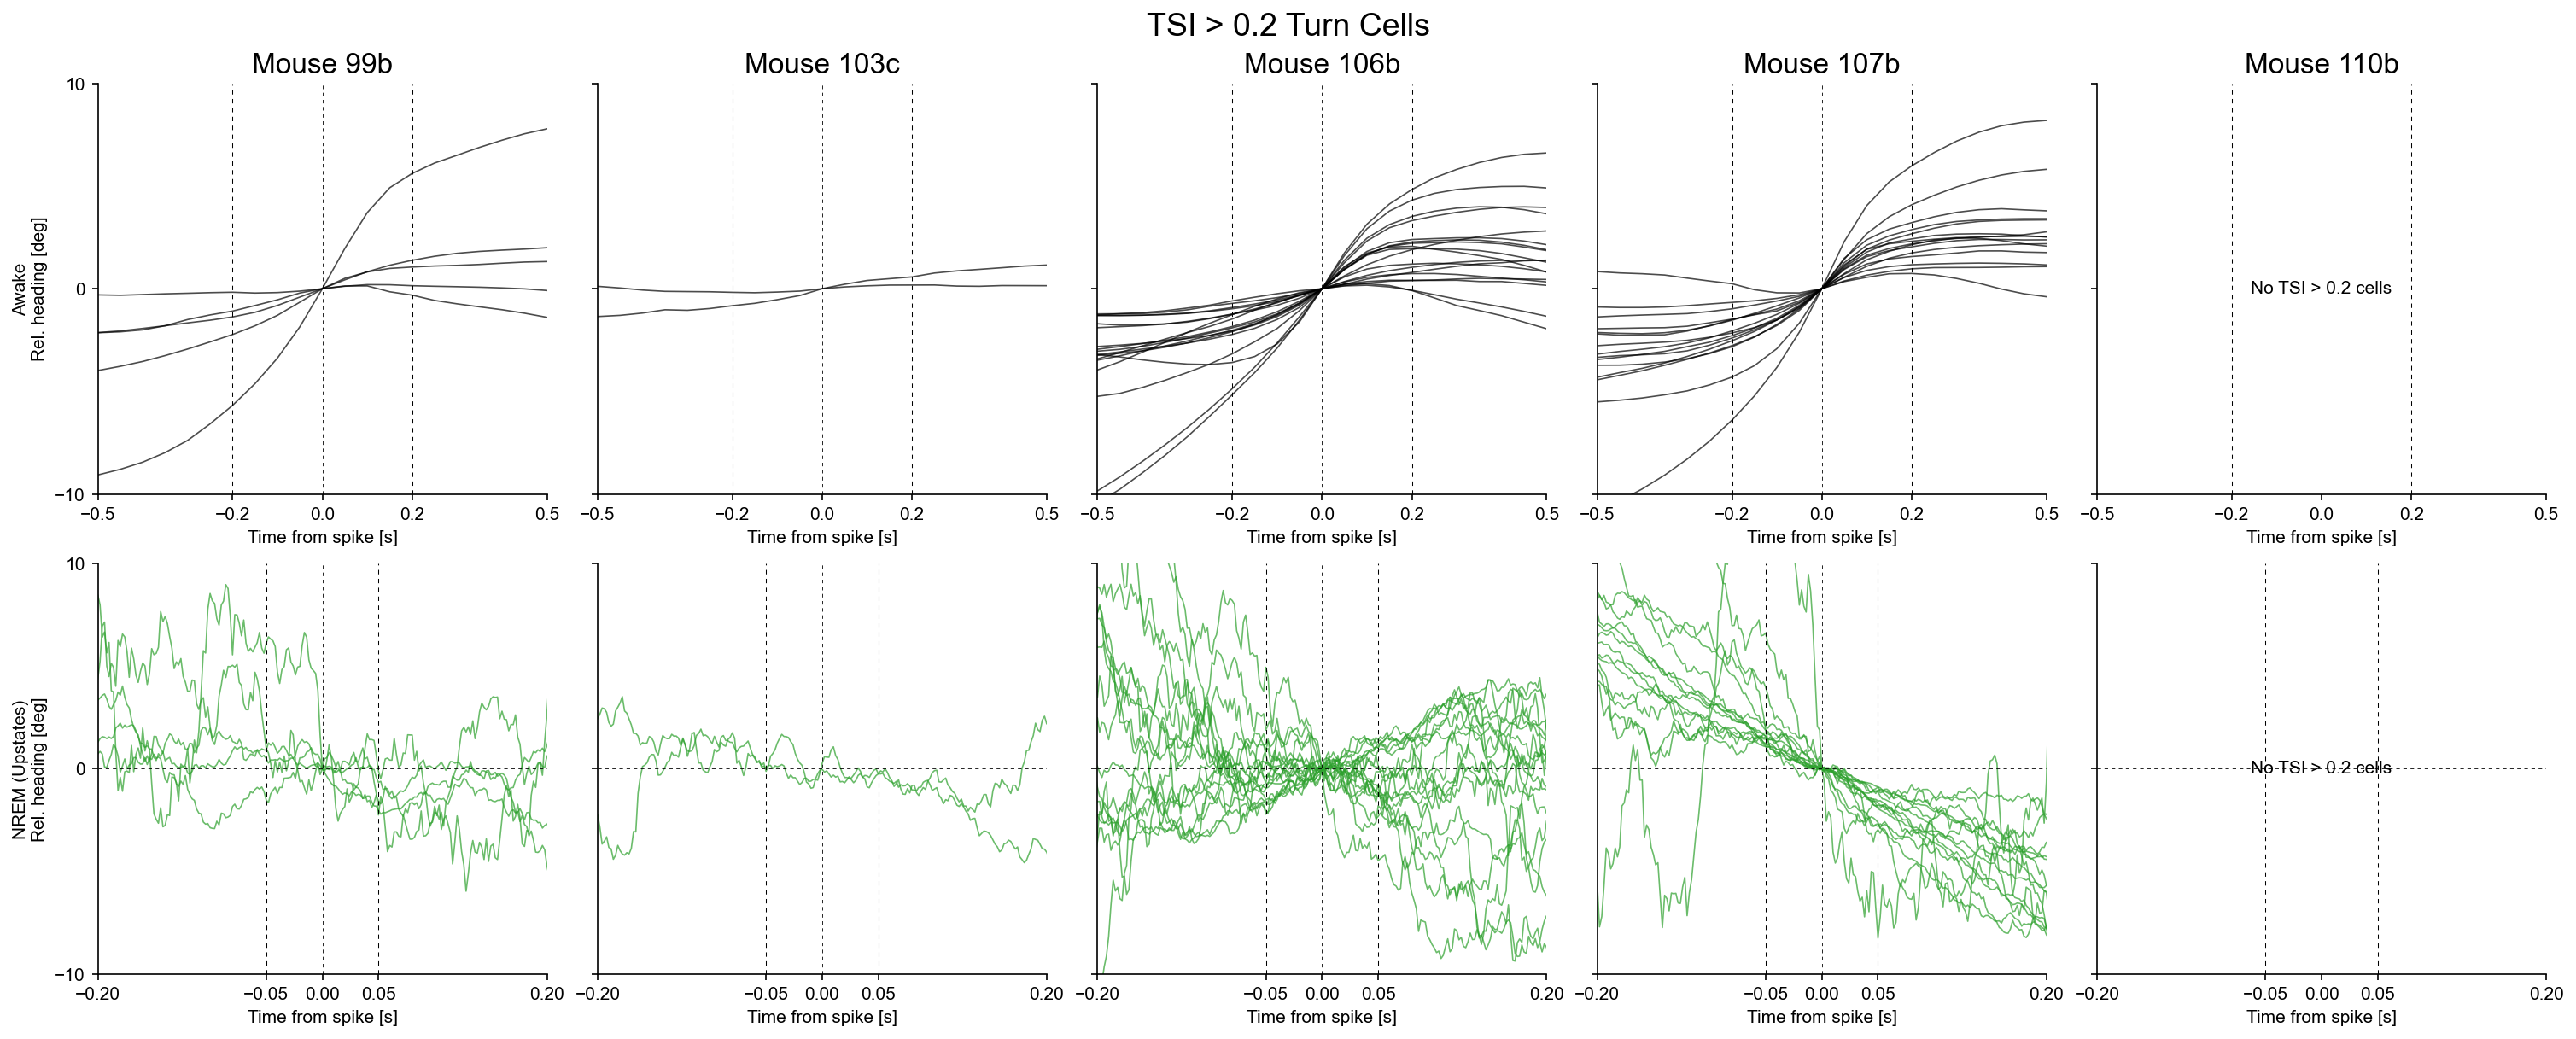

In [10]:
fig, axes = plt.subplots(
    2, len(MOUSE_IDS), figsize=(4 * len(MOUSE_IDS), 8), sharey=True, squeeze=False
)
row_specs = [
    ("Awake", sta_original, (-0.5, 0.5), [-0.5, -0.2, 0, 0.2, 0.5], 0.2, "k"),
    ("NREM (Upstates)", sta_nrem, (-0.2, 0.2), [-0.2, -0.05, 0, 0.05, 0.2], 0.05, "tab:green"),
]

for mouse_idx, mouse_id in enumerate(MOUSE_IDS):
    mouse_mask = (tsi > 0.2) & (midx == mouse_idx)

    for row_idx, (state, sta, xlim, xticks, threshold, color) in enumerate(row_specs):
        ax = axes[row_idx, mouse_idx]
        ax.plot(
            sta.t, sta.d[:, mouse_mask], color=color, alpha=0.7, linewidth=0.8
        )

        if not np.any(mouse_mask):
            ax.text(
                0.5, 0.5, "No TSI > 0.2 cells",
                transform=ax.transAxes, ha="center", va="center",
            )

        ax.set_xlim(xlim)
        ax.set_ylim((-10, 10))
        ax.set_xticks(xticks)
        ax.set_yticks([-10, 0, 10])
        ax.axhline(0, color="k", linestyle=dashed_style, linewidth=0.4)
        ax.axvline(0, color="k", linestyle=dashed_style, linewidth=0.4)
        ax.axvline(threshold, color="k", linestyle=dashed_style, linewidth=0.5)
        ax.axvline(-threshold, color="k", linestyle=dashed_style, linewidth=0.5)
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.set_xlabel("Time from spike [s]")

        if mouse_idx == 0:
            ax.set_ylabel(f"{state}\nRel. heading [deg]")

    axes[0, mouse_idx].set_title(f"Mouse {mouse_id}", fontsize=16)

fig.suptitle("TSI > 0.2 Turn Cells", fontsize=18)
# plt.savefig(FIGURES_DIR / "sta_cw_turns_per_mouse.png", format='png', bbox_inches='tight')
# plt.savefig(FIGURES_DIR / "sta_cw_turns_per_mouse.svg", format='svg', bbox_inches='tight')
plt.show()

In [21]:
vd = nap.load_file(PROCESSED_DIR / "dual" / "107b" / "virtual_hd.npz")
vd

Time (s)
----------  -------
10271.0005  90.4989
10271.0015  90.4989
10271.0025  90.4989
10271.0035  90.4989
10271.0045  90.4989
10271.0055  90.4989
10271.0065  90.4989
...
80625.9935  70.4991
80625.9945  70.4991
80625.9955  70.4991
80625.9965  70.4991
80625.9975  70.4991
80625.9985  70.4991
80625.9995  70.4991
dtype: float64, shape: (36269000,)

In [119]:
import numpy as np
import pynapple as nap


def generate_poisson_spikes(
    t_start: float,
    t_end: float,
    n_units: int,
    *,
    min_rate_hz: float = 1.0,
    max_rate_hz: float = 20.0,
    seed: int | None = None,
) -> nap.TsGroup:
    rng = np.random.default_rng(seed)
    duration = t_end - t_start
    rates = rng.uniform(min_rate_hz, max_rate_hz, size=n_units)

    time_support = nap.IntervalSet(
        start=t_start,
        end=t_end,
        time_units="s",
    )

    spikes = {}
    for unit_id, rate_hz in enumerate(rates):
        n_spikes = rng.poisson(rate_hz * duration)
        timestamps = np.sort(
            rng.uniform(t_start, t_end, size=n_spikes)
        )
        spikes[unit_id] = nap.Ts(
            t=timestamps,
            time_units="s",
            time_support=time_support,
        )

    return nap.TsGroup(
        spikes,
        time_support=time_support,
    )

spikes = generate_poisson_spikes(
    t_start=1000,
    t_end=1500,
    n_units=10,
    min_rate_hz=2,
    max_rate_hz=10,
    seed=42,
)
spikes

  Index    rate
-------  ------
      0   8.144
      1   5.522
      2   8.838
      3   7.298
      4   2.746
      5   9.776
      6   8.104
      7   8.312
      8   3.142
      9   5.656